# Feature Engineering

This notebook prepares the cleaned insurance dataset for machine learning.

The following preprocessing steps are performed:

- Feature selection
- Train-test split
- Categorical feature encoding
- Numerical feature scaling
- Class imbalance handling
- Export of processed datasets

In [1]:
# Import all required libraries for feature engineering
# and data preprocessing.

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler



In [2]:
# Load the cleaned dataset generated during
# exploratory data analysis.

df = pd.read_csv("../data/processed/insurance_clean.csv")

# Display dataset information including
# data types and missing values.

df.info()

# Verify that the cleaned dataset
# contains no missing values.

df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 1680909 entries, 0 to 1680908
Data columns (total 21 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   individual_id        1680909 non-null  float64
 1   address_id           1680909 non-null  float64
 2   curr_ann_amt         1680909 non-null  float64
 3   days_tenure          1680909 non-null  float64
 4   cust_orig_date       1680909 non-null  str    
 5   age_in_years         1680909 non-null  int64  
 6   date_of_birth        1680909 non-null  str    
 7   latitude             1427190 non-null  float64
 8   longitude            1427190 non-null  float64
 9   city                 1668842 non-null  str    
 10  state                1680909 non-null  str    
 11  county               1668842 non-null  str    
 12  income               1680909 non-null  float64
 13  has_children         1680909 non-null  float64
 14  length_of_residence  1680909 non-null  float64
 15  marital_s

individual_id               0
address_id                  0
curr_ann_amt                0
days_tenure                 0
cust_orig_date              0
age_in_years                0
date_of_birth               0
latitude               253719
longitude              253719
city                    12067
state                       0
county                  12067
income                      0
has_children                0
length_of_residence         0
marital_status              0
home_market_value       92286
home_owner                  0
college_degree              0
good_credit                 0
Churn                       0
dtype: int64

In [3]:
# Select only the features required
# for the first machine learning model.

selected_features = [
    "age_in_years",
    "income",
    "curr_ann_amt",
    "days_tenure",
    "length_of_residence",
    "marital_status",
    "home_owner",
    "college_degree",
    "good_credit",
    "Churn"
]

df = df[selected_features]

df.isnull().sum()


age_in_years           0
income                 0
curr_ann_amt           0
days_tenure            0
length_of_residence    0
marital_status         0
home_owner             0
college_degree         0
good_credit            0
Churn                  0
dtype: int64

In [4]:
# Encode all categorical features

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

categorical_features = [
    "marital_status"
]

for column in categorical_features:
    df[column] = encoder.fit_transform(df[column])


df.head()

df.select_dtypes(include="object").columns

df.info()




<class 'pandas.DataFrame'>
RangeIndex: 1680909 entries, 0 to 1680908
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   age_in_years         1680909 non-null  int64  
 1   income               1680909 non-null  float64
 2   curr_ann_amt         1680909 non-null  float64
 3   days_tenure          1680909 non-null  float64
 4   length_of_residence  1680909 non-null  float64
 5   marital_status       1680909 non-null  int64  
 6   home_owner           1680909 non-null  float64
 7   college_degree       1680909 non-null  float64
 8   good_credit          1680909 non-null  float64
 9   Churn                1680909 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 128.2 MB


In [5]:
# Features and target variable

X = df.drop("Churn", axis=1)
y = df["Churn"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


# Standardize the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)



# Logistic Regression is the first model and prediction

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)


# Evaluation the model

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("Recall :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))


Accuracy : 0.6054250376284275
Precision : 0.17406024949005786
Recall : 0.6484195290894523
F1 Score : 0.2744482428551894


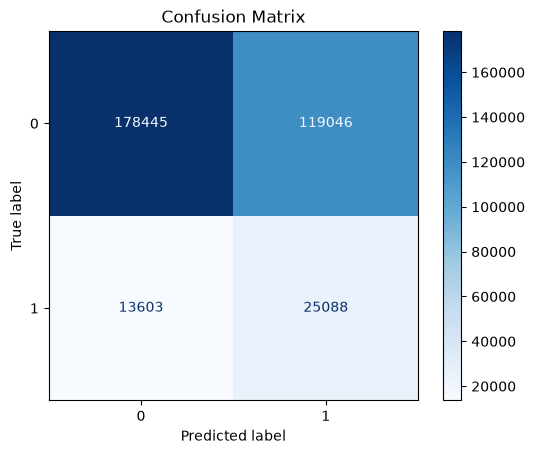

In [6]:
# Create a Confusion Matrix 

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()



In [7]:
# Compute the ROC-AUC

from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)


ROC-AUC: 0.6871093549458527


In [8]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

feature_importance["Abs"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Abs",
    ascending=False
)

feature_importance


,Feature,Coefficient,Abs
3,days_tenure,-0.604263,0.604263
2,curr_ann_amt,0.068662,0.068662
4,length_of_residence,-0.062763,0.062763
7,college_degree,-0.030617,0.030617
0,age_in_years,0.026217,0.026217
5,marital_status,-0.021555,0.021555
8,good_credit,-0.013574,0.013574
1,income,-0.004977,0.004977
6,home_owner,0.004820,0.004820


In [9]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall   :", recall_score(y_test, y_pred_tree))
print("F1 Score :", f1_score(y_test, y_pred_tree))

import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance



Accuracy : 0.8264957671737333
Precision: 0.24307917735098644
Recall   : 0.24010751854436432
F1 Score : 0.2415842099104136


,Feature,Importance
2,curr_ann_amt,0.334183
3,days_tenure,0.322785
1,income,0.099862
0,age_in_years,0.096254
4,length_of_residence,0.091128
7,college_degree,0.016029
5,marital_status,0.014343
6,home_owner,0.012939
8,good_credit,0.012476


In [10]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance


Accuracy : 0.8674081301199945
Precision: 0.41903792173482307
Recall   : 0.3935540564989274
F1 Score : 0.40589638673046424


,Feature,Importance
3,days_tenure,0.350512
2,curr_ann_amt,0.326824
0,age_in_years,0.125338
1,income,0.089381
4,length_of_residence,0.071683
5,marital_status,0.011678
8,good_credit,0.008642
6,home_owner,0.007992
7,college_degree,0.007949


CV F1 Scores: [0.41489379 0.41185497 0.41092813]
Mean F1: 0.41255896305616274


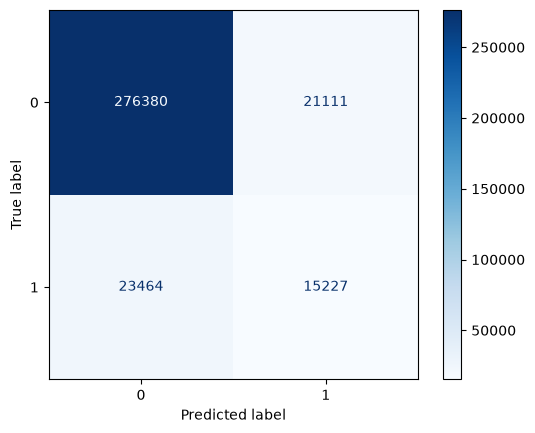

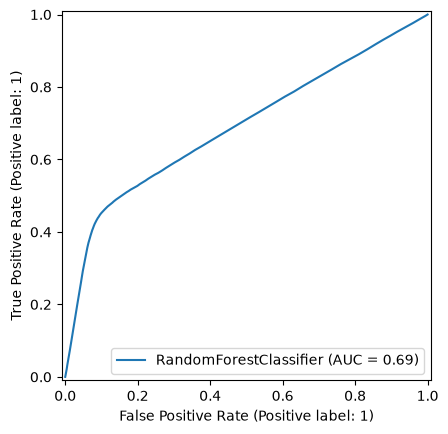

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    cmap="Blues"
)

from sklearn.metrics import roc_auc_score

y_prob = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, y_prob)

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    X,
    y,
    cv=3,
    scoring="f1",
    n_jobs=-1,
    error_score="raise"
)

print("CV F1 Scores:", scores)
print("Mean F1:", scores.mean())



Top 15 Features:
days_tenure            0.350512
curr_ann_amt           0.326824
age_in_years           0.125338
income                 0.089381
length_of_residence    0.071683
marital_status         0.011678
good_credit            0.008642
home_owner             0.007992
college_degree         0.007949
dtype: float64


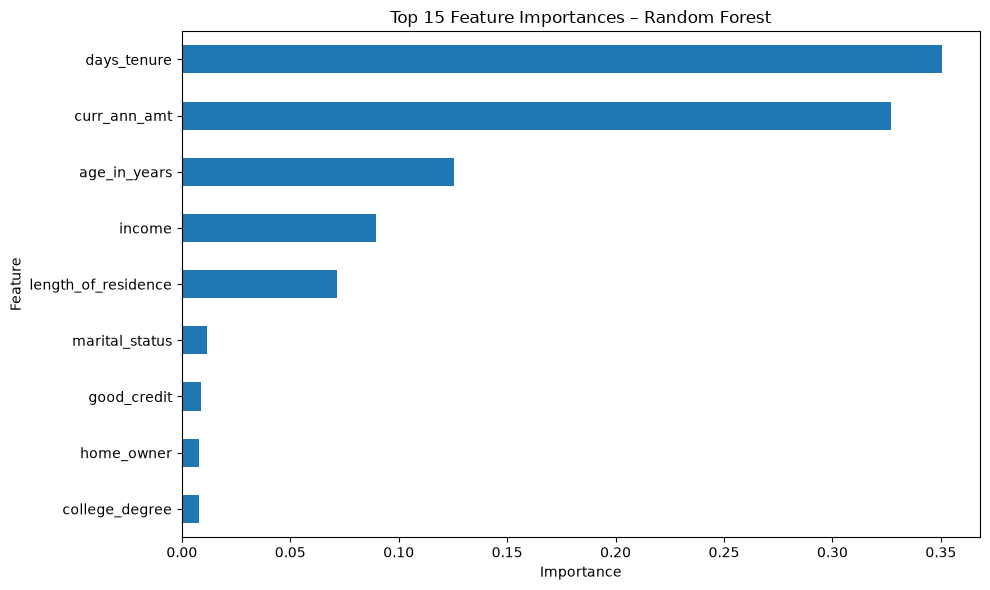

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature Importance des Random Forest
feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Features:")
print(feature_importance.head(15))

# Visualisierung
plt.figure(figsize=(10, 6))
feature_importance.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Feature Importances – Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [ ]:
### Permutation Importance
#Permutation importance shows that `days_tenure` is the strongest predictor, followed by age and length of residence. Other features contribute only marginally to the model's predictive performance.

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values("importance_mean", ascending=False)

print("Permutation Importance:")
print(perm_df.head(15))


c:\GitHub\motorguard-ai\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Permutation Importance:
               feature  importance_mean  importance_std
3          days_tenure         0.293805        0.000412
0         age_in_years         0.018127        0.000991
4  length_of_residence         0.014086        0.000890
7       college_degree         0.006639        0.000382
5       marital_status         0.002009        0.001010
1               income         0.001092        0.001122
2         curr_ann_amt         0.000117        0.000685
8          good_credit        -0.001937        0.000498
6           home_owner        -0.002481        0.000235


In [16]:
### XGBoost Model
# XGBoost is introduced as a third model to compare its performance with Logistic Regression and
# Random Forest for customer churn prediction.

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

print("XGBoost model trained successfully.")

### XGBoost Evaluation
# The trained XGBoost model is evaluated on the test set using precision, recall, F1-score, and ROC-AUC.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Predictions
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_roc_auc = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance")
print("-------------------")
print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1 Score:  {xgb_f1:.4f}")
print(f"ROC-AUC:   {xgb_roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))




XGBoost model trained successfully.
XGBoost Performance
-------------------
Accuracy:  0.8845
Precision: 0.4964
Recall:    0.2149
F1 Score:  0.2999
ROC-AUC:   0.6946

Confusion Matrix:
[[289055   8436]
 [ 30377   8314]]


In [17]:
### Threshold Optimization

# The default classification threshold of 0.5 may not provide the best balance between precision and recall.
# We therefore evaluate different thresholds to improve churn detection.

import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.10, 0.71, 0.05)

results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_xgb >= threshold).astype(int)

    results.append({
        "threshold": threshold,
        "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
        "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
        "f1": f1_score(y_test, y_pred_threshold, zero_division=0)
    })

threshold_results = pd.DataFrame(results)

print(threshold_results.round(4))

best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax(),
    "threshold"
]

best_f1 = threshold_results["f1"].max()

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 Score: {best_f1:.4f}")




    threshold  precision  recall      f1
0        0.10     0.4242  0.4644  0.4434
1        0.15     0.4587  0.4519  0.4553
2        0.20     0.4732  0.4434  0.4578
3        0.25     0.4794  0.4374  0.4575
4        0.30     0.4844  0.4282  0.4546
5        0.35     0.4872  0.4207  0.4515
6        0.40     0.4910  0.4112  0.4476
7        0.45     0.4932  0.3959  0.4392
8        0.50     0.4964  0.2149  0.2999
9        0.55     0.5178  0.0034  0.0067
10       0.60     0.5517  0.0008  0.0017
11       0.65     0.5000  0.0002  0.0005
12       0.70     0.0000  0.0000  0.0000
Best threshold: 0.20
Best F1 Score: 0.4578


### Threshold Optimization Result

The default threshold of 0.5 resulted in poor churn recall. Lowering the threshold to 0.20 improved the F1 score from 0.30 to 0.46 and increased recall from 21.5% to 44.3%.

In [19]:
### Model Comparison

# Logistic Regression, Random Forest
# and XGBoost are compared using the same test set and evaluation metrics.

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Logistic Regression
y_pred_lr = model.predict(X_test_scaled)
y_prob_lr = model.predict_proba(X_test_scaled)[:, 1]

# Random Forest
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# XGBoost with optimized threshold
best_threshold = 0.20
y_pred_xgb_opt = (y_prob_xgb >= best_threshold).astype(int)

# Model comparison
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost (Threshold 0.20)"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb_opt)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb_opt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb_opt)
    ],
    "F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb_opt)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

comparison.round(4)



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.6054,0.1741,0.6484,0.2744,0.6871
1,Random Forest,0.8674,0.4190,0.3936,0.4059,0.6908
2,XGBoost (Threshold 0.20),0.8791,0.4732,0.4434,0.4578,0.6946


### XGBoost Hyperparameter Tuning

A randomized hyperparameter search is used to improve the XGBoost model while keeping the computational cost manageable.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 150, 200, 250],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9]
}

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)

print("\nBest CV F1:")
print(random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'subsample': 0.7, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.9}

Best CV F1:
0.2982013322012165


### Cross-Validated Threshold Selection

The optimal classification threshold is selected using out-of-fold predictions on the training data to avoid using the test set for model selection.

In [21]:
from sklearn.model_selection import cross_val_predict

# Create XGBoost with the best hyperparameters
xgb_tuned = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Out-of-fold probability predictions on training data
y_train_oof_prob = cross_val_predict(
    xgb_tuned,
    X_train,
    y_train,
    cv=3,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Find the threshold with the best F1 score
thresholds = np.arange(0.10, 0.71, 0.01)

threshold_scores = []

for threshold in thresholds:
    y_train_oof_pred = (y_train_oof_prob >= threshold).astype(int)

    threshold_scores.append(
        f1_score(
            y_train,
            y_train_oof_pred,
            zero_division=0
        )
    )

best_idx = np.argmax(threshold_scores)
best_threshold_cv = thresholds[best_idx]
best_cv_f1 = threshold_scores[best_idx]

print(f"Best CV threshold: {best_threshold_cv:.2f}")
print(f"Best CV F1: {best_cv_f1:.4f}")


Best CV threshold: 0.22
Best CV F1: 0.4643


### Final XGBoost Model

The final XGBoost model is trained using the optimized hyperparameters and evaluated on the unseen test set using the cross-validated classification threshold.

In [22]:
# Train final XGBoost model with optimized hyperparameters

final_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_train, y_train)

# Test-set probabilities
y_test_prob_final = final_xgb.predict_proba(X_test)[:, 1]

# Apply cross-validated threshold
y_test_pred_final = (
    y_test_prob_final >= best_threshold_cv
).astype(int)

# Final evaluation
final_accuracy = accuracy_score(y_test, y_test_pred_final)
final_precision = precision_score(y_test, y_test_pred_final)
final_recall = recall_score(y_test, y_test_pred_final)
final_f1 = f1_score(y_test, y_test_pred_final)
final_roc_auc = roc_auc_score(y_test, y_test_prob_final)

print("Final XGBoost Performance")
print("-------------------------")
print(f"Threshold: {best_threshold_cv:.2f}")
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1 Score:  {final_f1:.4f}")
print(f"ROC-AUC:   {final_roc_auc:.4f}")



Final XGBoost Performance
-------------------------
Threshold: 0.22
Accuracy:  0.8796
Precision: 0.4753
Recall:    0.4421
F1 Score:  0.4581
ROC-AUC:   0.6948


### Final Model – Confusion Matrix

The confusion matrix shows the final classification performance of the optimized XGBoost model on the unseen test set.

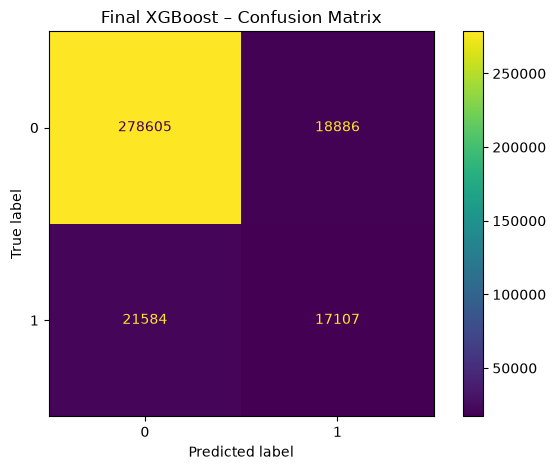

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred_final
)

plt.title("Final XGBoost – Confusion Matrix")
plt.tight_layout()
plt.show()


### Save Final Model

The optimized XGBoost model is saved for later use in the prediction API and deployment pipeline.

In [24]:
import joblib
from pathlib import Path

# Create models directory if it does not exist
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

# Save final model
model_path = models_dir / "xgboost_churn_model.joblib"

joblib.dump(final_xgb, model_path)

print(f"Model saved to: {model_path}")


Model saved to: ..\models\xgboost_churn_model.joblib


### Final Model Metrics

The final XGBoost model achieves an F1 score of 0.458 and a ROC-AUC of 0.695 on the unseen test set using a cross-validated decision threshold of 0.22.

In [25]:
# Save final model metrics

final_metrics = pd.DataFrame([{
    "model": "XGBoost",
    "threshold": best_threshold_cv,
    "accuracy": final_accuracy,
    "precision": final_precision,
    "recall": final_recall,
    "f1": final_f1,
    "roc_auc": final_roc_auc
}])

metrics_path = Path("../reports/final_model_metrics.csv")

final_metrics.to_csv(metrics_path, index=False)

print(f"Metrics saved to: {metrics_path}")
print(final_metrics.round(4))


Metrics saved to: ..\reports\final_model_metrics.csv
     model  threshold  accuracy  precision  recall      f1  roc_auc
0  XGBoost       0.22    0.8796     0.4753  0.4421  0.4581   0.6948
